<a href="https://colab.research.google.com/github/ompandey0211/Modi_Reviews_Sentiment_Analysis/blob/main/comment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving modi_reviews.csv to modi_reviews.csv


In [ ]:
import pandas as pd

df = pd.read_csv("modi_reviews.csv")
df.head()

,Unnamed: 0,User,Tweet
0,0,advosushildixit,@anjanaomkashyap I am seeing you as future #bj...
1,1,jiaeur,#LokSabhaElections2019 \n23rd May 2019 will re...
2,2,PVenkatGandhi,#LokSabhaElections2019 \n23rd May 2019 will re...
3,3,TheNirbhay1,PM Modi creates a new record of being the only...
4,4,ShakeChilli,@abhijitmajumder Appointment of Successor! \n\...


In [ ]:
df.shape

(25688, 3)

In [ ]:
df.columns


Index(['Unnamed: 0', 'User', 'Tweet'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25688 entries, 0 to 25687
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  25688 non-null  int64 
 1   User        25683 non-null  object
 2   Tweet       25683 non-null  object
dtypes: int64(1), object(2)
memory usage: 602.2+ KB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
User,5
Tweet,5


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [ ]:
df.rename(columns={
    "User":"user",
    "Tweet":"tweet"
}, inplace=True)

In [ ]:
df.drop_duplicates(subset="tweet", inplace=True)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.head()

,user,tweet
0,advosushildixit,@anjanaomkashyap I am seeing you as future #bj...
1,jiaeur,#LokSabhaElections2019 \n23rd May 2019 will re...
2,PVenkatGandhi,#LokSabhaElections2019 \n23rd May 2019 will re...
3,TheNirbhay1,PM Modi creates a new record of being the only...
4,ShakeChilli,@abhijitmajumder Appointment of Successor! \n\...


In [ ]:
df["tweet_length"] = df["tweet"].apply(len)

In [ ]:
df["tweet_length"].describe()

,tweet_length
count,25683.000000
mean,219.685901
std,81.103602
min,21.000000
25%,163.000000
50%,231.000000
75%,277.000000
max,995.000000


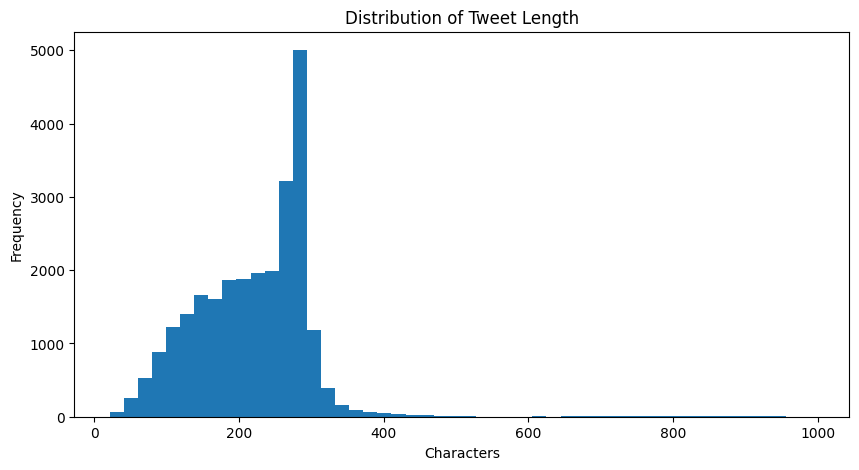

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["tweet_length"], bins=50)
plt.title("Distribution of Tweet Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 25683
Columns: 3


In [ ]:
df["word_count"] = df["tweet"].apply(lambda x: len(str(x).split()))
df["word_count"].describe()

,word_count
count,25683.000000
mean,31.641514
std,12.366733
min,3.000000
25%,22.000000
50%,32.000000
75%,41.000000
max,102.000000


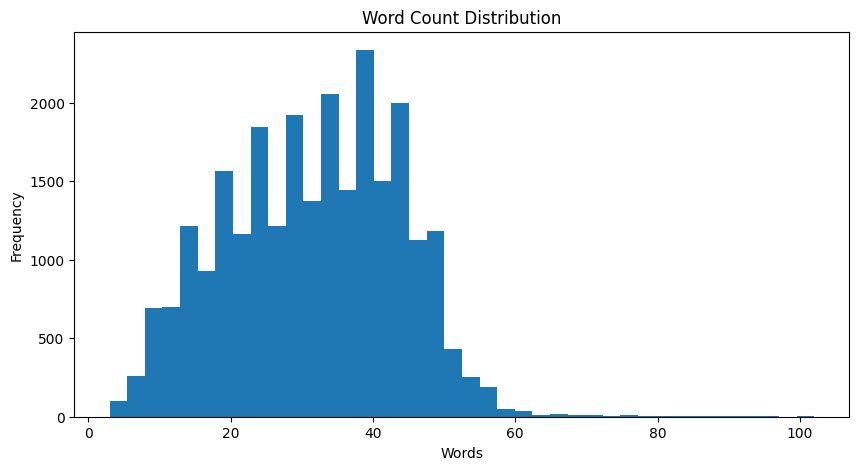

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(df["word_count"], bins=40)
plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df["avg_word_length"] = df["tweet"].apply(
    lambda x: sum(len(word) for word in str(x).split()) / len(str(x).split())
)

df["avg_word_length"].describe()

,avg_word_length
count,25683.000000
mean,6.199232
std,1.414993
min,3.142857
25%,5.250000
50%,5.894737
75%,6.789474
max,21.444444


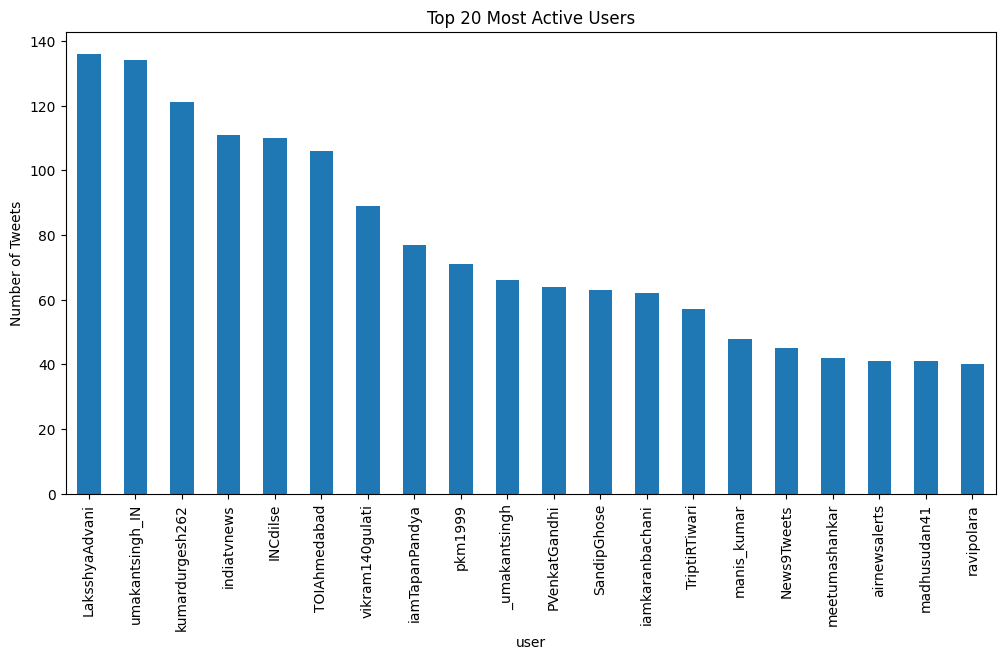

In [ ]:
top_users = df["user"].value_counts().head(20)

plt.figure(figsize=(12,6))
top_users.plot(kind="bar")
plt.title("Top 20 Most Active Users")
plt.ylabel("Number of Tweets")
plt.show()

In [ ]:
df["user"].value_counts().head(10)

,count
user,
LaksshyaAdvani,136
umakantsingh_IN,134
kumardurgesh262,121
indiatvnews,111
INCdilse,110
TOIAhmedabad,106
vikram140gulati,89
iamTapanPandya,77
pkm1999,71


In [ ]:
import re

hashtags = []

for tweet in df["tweet"]:
    hashtags.extend(re.findall(r"#(\w+)", str(tweet)))

from collections import Counter

Counter(hashtags).most_common(20)

[('LokSabhaElections2019', 9645),
 ('BJP', 6994),
 ('NarendraModi', 5360),
 ('RahulGandhi', 2788),
 ('Modi', 1203),
 ('Congress', 1112),
 ('bjp', 1087),
 ('India', 790),
 ('Elections2019', 661),
 ('MainBhiChowkidar', 619),
 ('PMModi', 606),
 ('PhirEkBaarModiSarkar', 593),
 ('LoksabhaElections2019', 593),
 ('ModiOnceMore', 527),
 ('narendramodi', 400),
 ('NamoAgain', 367),
 ('ElectionCommission', 313),
 ('BJP4India', 249),
 ('INC', 247),
 ('VoteKar', 243)]

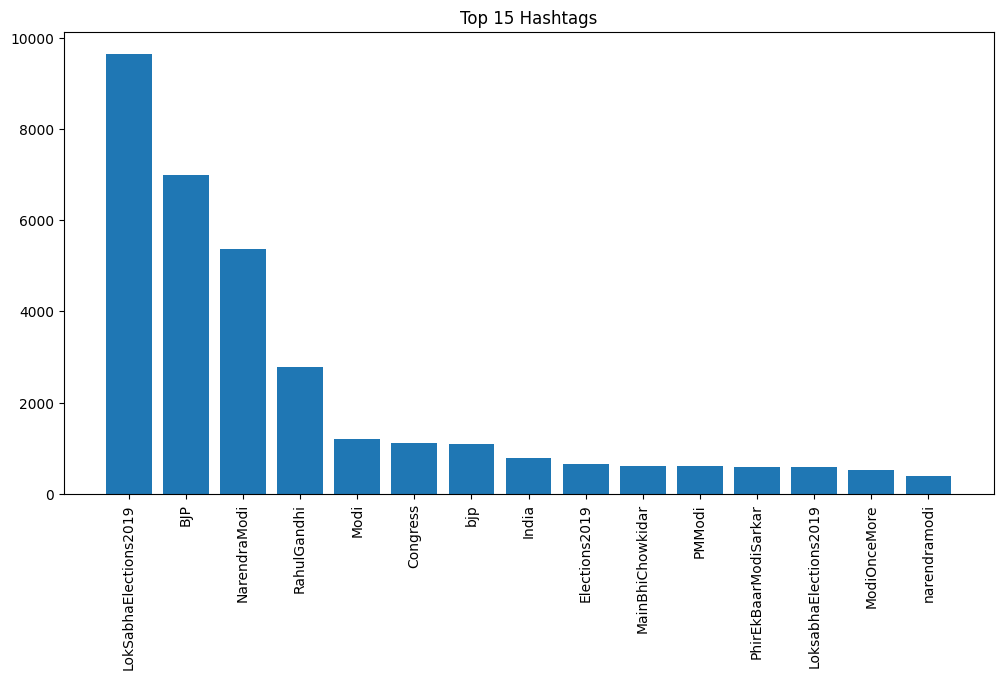

In [ ]:
top_hashtags = Counter(hashtags).most_common(15)

labels = [x[0] for x in top_hashtags]
values = [x[1] for x in top_hashtags]

plt.figure(figsize=(12,6))
plt.bar(labels, values)
plt.xticks(rotation=90)
plt.title("Top 15 Hashtags")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words="english", ngram_range=(2,2))
X = cv.fit_transform(df["tweet"])

sum_words = X.sum(axis=0)

words_freq = [
    (word, sum_words[0, idx])
    for word, idx in cv.vocabulary_.items()
]

words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

words_freq[:20]

[('pm narendramodi', np.int64(1744)),
 ('narendramodi ji', np.int64(1261)),
 ('modi ji', np.int64(1174)),
 ('pm modi', np.int64(1057)),
 ('narendra modi', np.int64(977)),
 ('narendramodi amitshah', np.int64(854)),
 ('prime minister', np.int64(769)),
 ('narendramodi bjp4india', np.int64(646)),
 ('bjp4india narendramodi', np.int64(625)),
 ('narendramodi pmoindia', np.int64(605)),
 ('narendramodi rahulgandhi', np.int64(577)),
 ('narendramodi narendramodi', np.int64(525)),
 ('narendramodi bjp', np.int64(489)),
 ('narendramodi sir', np.int64(479)),
 ('pmoindia narendramodi', np.int64(453)),
 ('vote bjp', np.int64(433)),
 ('rahul gandhi', np.int64(432)),
 ('pm india', np.int64(399)),
 ('modi govt', np.int64(396)),
 ('bjp narendramodi', np.int64(393))]

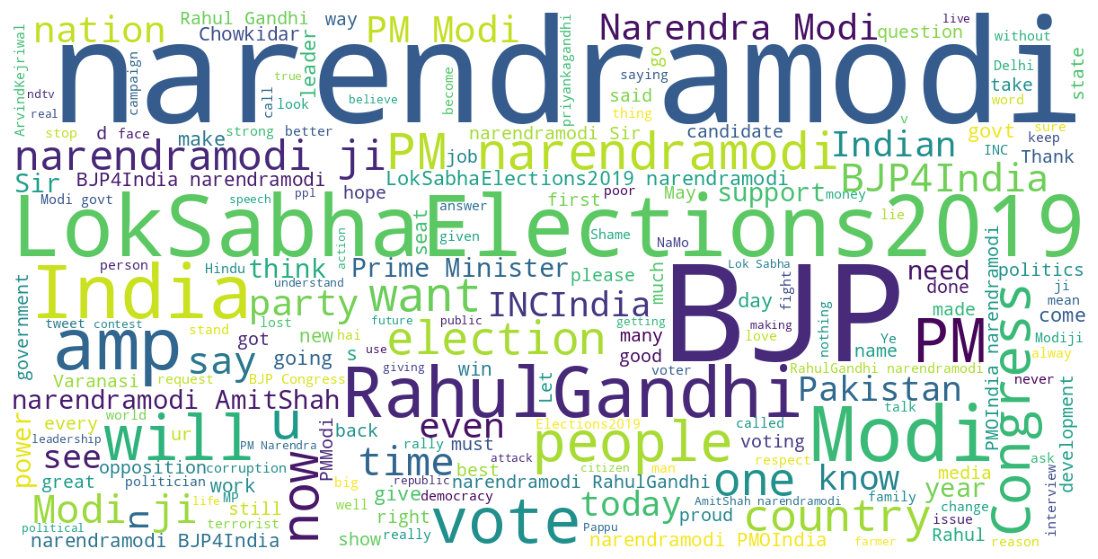

In [ ]:
from wordcloud import WordCloud

text = " ".join(df["tweet"])

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wc)
plt.axis("off")
plt.show()


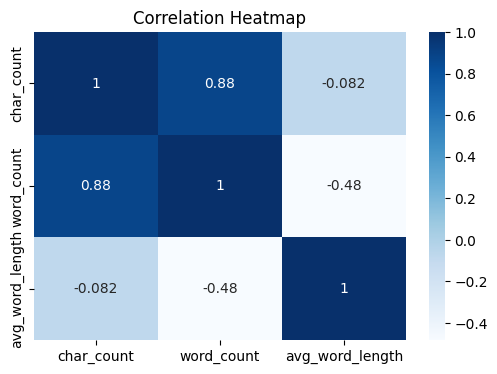

In [ ]:
import seaborn as sns

numeric = df[["char_count", "word_count", "avg_word_length"]]

plt.figure(figsize=(6,4))
sns.heatmap(numeric.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

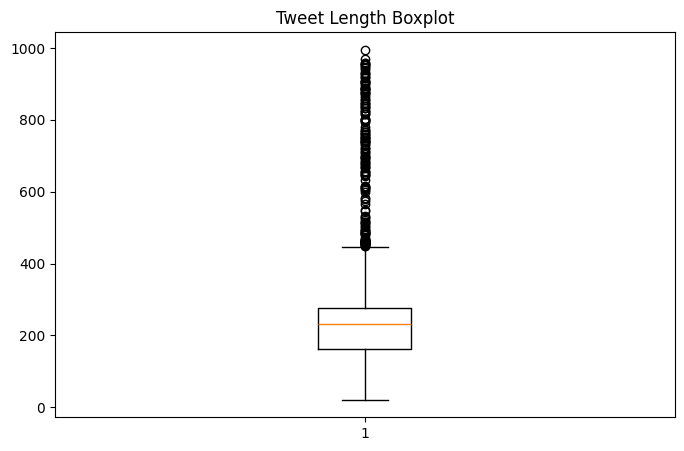

In [ ]:
plt.figure(figsize=(8,5))
plt.boxplot(df["char_count"])
plt.title("Tweet Length Boxplot")
plt.show()

In [ ]:
Q1 = df["char_count"].quantile(0.25)
Q3 = df["char_count"].quantile(0.75)
IQR = Q3 - Q1

print("Lower Limit:", Q1 - 1.5 * IQR)
print("Upper Limit:", Q3 + 1.5 * IQR)

Lower Limit: -8.0
Upper Limit: 448.0


In [ ]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags (#)
    text = re.sub(r'#', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(words)

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
df["clean_tweet"] = df["tweet"].apply(clean_text)

In [ ]:
df[["tweet", "clean_tweet"]].head(10)

,tweet,clean_tweet
0,@anjanaomkashyap I am seeing you as future #bj...,seeing future bjp spokesperson good luck anjan...
1,#LokSabhaElections2019 \n23rd May 2019 will re...,loksabhaelections may reveal even ecisveep cou...
2,#LokSabhaElections2019 \n23rd May 2019 will re...,loksabhaelections may reveal even could help m...
3,PM Modi creates a new record of being the only...,modi creates new record democratic country con...
4,@abhijitmajumder Appointment of Successor! \n\...,appointment successor god forbid allow bjp sto...
5,Which of the following should be top priority ...,following top priority modi government loksabh...
6,After 5yrs of Modi 🙁\n\n-SC vs SC\n-EC vs EC\n...,yr modi medium medium rbi rbi cbi cbi friend f...
7,@RenukaJain6\nI still remember your video mass...,still remember video massage disappointed bjp ...
8,#bjp @BJP4India @INCIndia @INCKarnataka how mu...,bjp much think modi spends tax money fake phot...
9,#AzadPrediction\n#LokSabhaElections2019 \n\nBJ...,azadprediction loksabhaelections bjp nda take ...


In [ ]:
(df["clean_tweet"] == "").sum()

np.int64(0)

In [ ]:
df = df[df["clean_tweet"] != ""]

In [ ]:
df.to_csv("cleaned_modi_reviews.csv", index=False)

In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.6 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [ ]:
def get_sentiment(text):
    score = analyzer.polarity_scores(text)
    compound = score["compound"]

    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [ ]:
df["sentiment"] = df["clean_tweet"].apply(get_sentiment)

In [ ]:
df[["clean_tweet", "sentiment"]].head(10)

,clean_tweet,sentiment
0,seeing future bjp spokesperson good luck anjan...,Positive
1,loksabhaelections may reveal even ecisveep cou...,Positive
2,loksabhaelections may reveal even could help m...,Positive
3,modi creates new record democratic country con...,Positive
4,appointment successor god forbid allow bjp sto...,Positive
5,following top priority modi government loksabh...,Positive
6,yr modi medium medium rbi rbi cbi cbi friend f...,Positive
7,still remember video massage disappointed bjp ...,Positive
8,bjp much think modi spends tax money fake phot...,Negative
9,azadprediction loksabhaelections bjp nda take ...,Neutral


In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
Positive,14026
Negative,7056
Neutral,4601


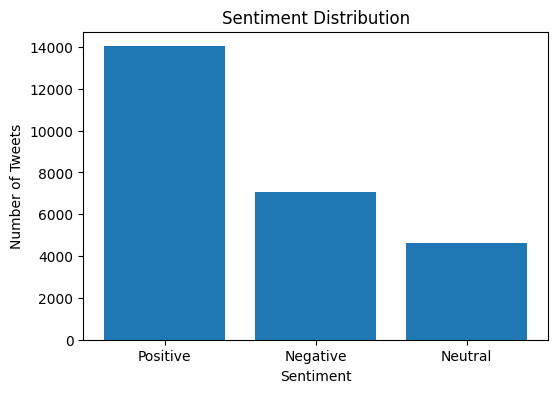

In [ ]:
import matplotlib.pyplot as plt

sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

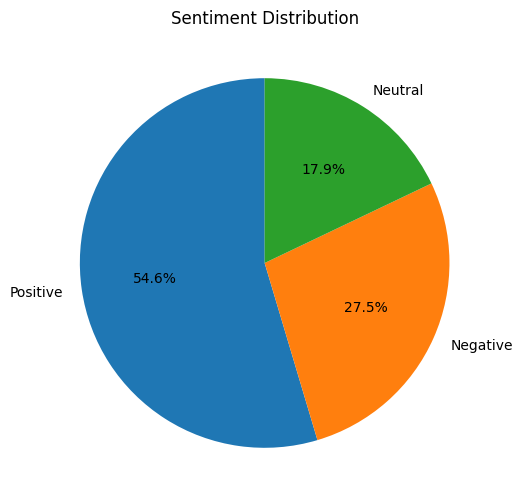

In [ ]:
plt.figure(figsize=(6, 6))
plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Sentiment Distribution")
plt.show()

In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
Positive,14026
Negative,7056
Neutral,4601


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

In [ ]:
X = tfidf.fit_transform(df["clean_tweet"])
y = df["sentiment"]

In [ ]:
print(X.shape)
print(y.shape)

(25683, 5000)
(25683,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(20546, 5000)
(5137, 5000)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

MultinomialNB()

In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train, y_train)

LinearSVC()

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7819739147362273


In [ ]:
nb_pred = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.6854195055479853


In [ ]:
svm_pred = svm.predict(X_test)

print("Linear SVM Accuracy:", accuracy_score(y_test, svm_pred))

Linear SVM Accuracy: 0.7975472065407826


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Linear SVM,0.797547
0,Logistic Regression,0.781974
1,Naive Bayes,0.685420


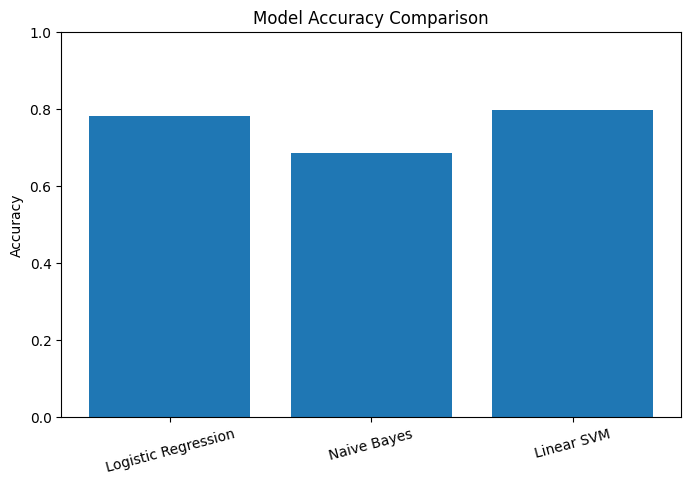

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Accuracy"])
plt.ylim(0,1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, svm_pred))


              precision    recall  f1-score   support

    Negative       0.77      0.73      0.75      1411
     Neutral       0.70      0.64      0.67       920
    Positive       0.84      0.88      0.86      2806

    accuracy                           0.80      5137
   macro avg       0.77      0.75      0.76      5137
weighted avg       0.79      0.80      0.80      5137



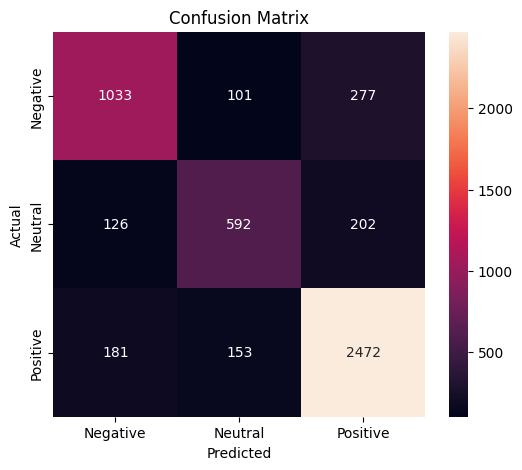

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=svm.classes_,
            yticklabels=svm.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
results

,Model,Accuracy
0,Logistic Regression,0.781974
1,Naive Bayes,0.685420
2,Linear SVM,0.797547


In [ ]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

    Negative       0.77      0.73      0.75      1411
     Neutral       0.70      0.64      0.67       920
    Positive       0.84      0.88      0.86      2806

    accuracy                           0.80      5137
   macro avg       0.77      0.75      0.76      5137
weighted avg       0.79      0.80      0.80      5137



In [ ]:
import joblib

joblib.dump(svm, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vector = tfidf.transform([cleaned])
    prediction = svm.predict(vector)[0]
    return prediction

In [ ]:
predict_sentiment("Modi is doing a great job for the country.")

'Positive'

In [ ]:
predict_sentiment("Worst government ever.")

'Negative'

In [ ]:
predict_sentiment("The Prime Minister addressed the nation today.")

'Neutral'

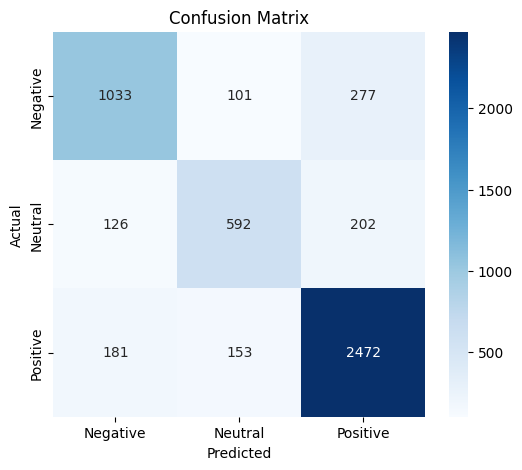

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=svm.classes_,
    yticklabels=svm.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

feature_names = tfidf.get_feature_names_out()

coef = svm.coef_

top_features = pd.DataFrame({
    "Feature": feature_names,
    "Weight": np.mean(np.abs(coef), axis=0)
})

top_features = top_features.sort_values("Weight", ascending=False)

top_features.head(20)

,Feature,Weight
4411,terrorist,4.127334
466,best,3.788405
1837,great,3.631676
4278,strong,3.494471
4868,win,3.438498
2454,like,3.417643
3299,party,3.393546
2579,love,3.354395
335,attack,3.221663
1696,free,3.060373


In [ ]:
import pandas as pd
import numpy as np

feature_names = tfidf.get_feature_names_out()

coef = svm.coef_

top_features = pd.DataFrame({
    "Feature": feature_names,
    "Weight": np.mean(np.abs(coef), axis=0)
})

top_features = top_features.sort_values(by="Weight", ascending=False)

top_features.head(20)

,Feature,Weight
4411,terrorist,4.127334
466,best,3.788405
1837,great,3.631676
4278,strong,3.494471
4868,win,3.438498
2454,like,3.417643
3299,party,3.393546
2579,love,3.354395
335,attack,3.221663
1696,free,3.060373


In [ ]:
feature_names = tfidf.get_feature_names_out()

positive_coef = svm.coef_[2]   # Positive class

top_positive = pd.DataFrame({
    "Word": feature_names,
    "Weight": positive_coef
}).sort_values(by="Weight", ascending=False)

top_positive.head(20)

,Word,Weight
466,best,4.852696
1837,great,4.521027
4278,strong,4.370016
4868,win,4.354415
3299,party,4.341863
2579,love,4.288740
2454,like,4.166061
1696,free,3.819129
957,congratulation,3.759051
3587,proud,3.753778


In [ ]:
negative_coef = svm.coef_[0]   # Negative class

top_negative = pd.DataFrame({
    "Word": feature_names,
    "Weight": negative_coef
}).sort_values(by="Weight")

top_negative.head(20)

,Word,Weight
466,best,-3.702399
2579,love,-3.329409
1837,great,-3.116464
1883,happy,-3.085333
4278,strong,-2.972609
3859,rich,-2.821428
1696,free,-2.631900
3299,party,-2.509155
1930,help,-2.466314
3837,respected,-2.345302


In [ ]:
import joblib

joblib.dump(svm, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [ ]:
!ls

cleaned_modi_reviews.csv  sample_data	       tfidf_vectorizer.pkl
modi_reviews.csv	  sentiment_model.pkl


In [ ]:
from google.colab import files

files.download("sentiment_model.pkl")
files.download("tfidf_vectorizer.pkl")
files.download("cleaned_modi_reviews.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>